
# 🧩 Mini-Proiect: Regresie și Îmbunătățire de Model



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
pd.set_option("display.max_columns", 100)  # arată până la 100 de coloane
pd.set_option("display.width", 100)        # lățimea maximă a liniei
df = pd.read_csv(url)
df.head(15)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


       carat    cut  color  clarity  depth  table  price      x      y      z
0      False  False  False    False  False  False  False  False  False  False
1      False  False  False    False  False  False  False  False  False  False
2      False  False  False    False  False  False  False  False  False  False
3      False  False  False    False  False  False  False  False  False  False
4      False  False  False    False  False  False  False  False  False  False
...      ...    ...    ...      ...    ...    ...    ...    ...    ...    ...
53935  False  False  False    False  False  False  False  False  False  False
53936  False  False  False    False  False  False  False  False  False  False
53937  False  False  False    False  False  False  False  False  False  False
53938  False  False  False    False  False  False  False  False  False  False
53939  False  False  False    False  False  False  False  False  False  False

[53940 rows x 10 columns]
Valori lipsă pe coloană:
carat      0

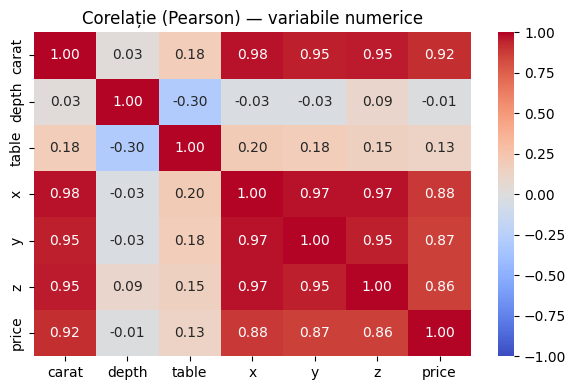

In [ ]:
print(df.isnull())

print("Valori lipsă pe coloană:")
print(df.isnull().sum())

df.info()

df["carat"].value_counts()
df["clarity"].value_counts()
df["cut"].value_counts()

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["carat","depth","table","x","y","z","price"]
corr_pearson = df[num_cols].corr(method="pearson") # Se calculează corelația
plt.figure(figsize=(6,4))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corelație (Pearson) — variabile numerice")
plt.tight_layout()
plt.show()


plt.show()

cut
Premium      4584.257704
Fair         4358.757764
Very Good    3981.759891
Good         3928.864452
Ideal        3457.541970
Name: price, dtype: float64
cut
Fair         3282.0
Premium      3185.0
Good         3050.5
Very Good    2648.0
Ideal        1810.0
Name: price, dtype: float64


Text(0, 0.5, 'Price')

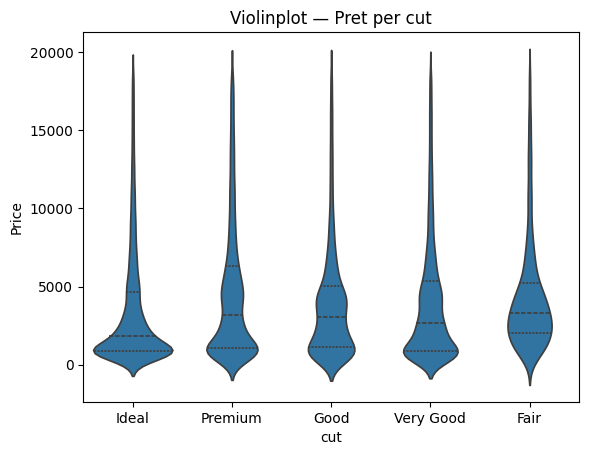

In [ ]:
print(df.groupby("cut")["price"].mean().sort_values(ascending=False))
print(df.groupby("cut")["price"].median().sort_values(ascending=False))


sns.violinplot(data=df, x="cut", y="price", inner="quartile")
plt.title("Violinplot — Pret per cut")
plt.xlabel("cut"); plt.ylabel("Price")

=== Linear Regression (univariată) ===
Coeficient (slope):  7768.910490
Intercept (bias):    -2261.911746


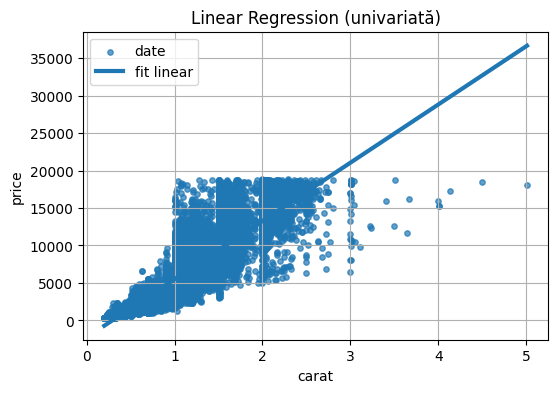

In [ ]:
# 🔹 3️⃣ Construiți un model inițial

# Tipuri posibile:
# - Linear Regression
# - Multiple Regression
# - Polynomial Regression

feature_cols = ["carat"]
target_col = "price"
x = df[feature_cols].values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)

print("=== Linear Regression (univariată) ===")
print(f"Coeficient (slope):  {model.coef_[0]:.6f}")
print(f"Intercept (bias):    {model.intercept_:.6f}")

# 7) Vizualizare: punctele + linia de regresie
xs = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)  # grid pe axa X
ys = model.predict(xs)                                  # linia estimată

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=15, alpha=0.7, label='date')
plt.plot(xs, ys, linewidth=3, label='fit linear')
plt.xlabel('carat')
plt.ylabel('price')
plt.title('Linear Regression (univariată)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# 🔹 4️⃣ Evaluați performanța modelului


# Calculați următoarele metrici:
# - RMSE (Root Mean Squared Error)
# - R² (coeficientul de determinare)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("Rmse:", rmse)
r2 = r2_score(y_test, y_pred_test)

print("R²:", r2)


Rmse: 1549.6414599768207
R²: 0.8489390686155808


In [ ]:
# 🔹 5️⃣ Îmbunătățiți modelul


# Încercați una sau mai multe dintre:
# - Normalizare / Standardizare
# - Regularizare (Ridge / Lasso)
# - Grad polinomial diferit
# - Schimbarea unor feature-uri
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

feature_cols = ["carat","x","y","z"]
target_col = "price"

X = df[feature_cols].values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Antrenăm modelul de regresie liniară
model = LinearRegression()
model.fit(X_train, y_train)

# 4) Facem predicții pe test
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Rmse multiple features:", rmse)  #1521.8093468210932 (mai mic)
r2 = r2_score(y_test, y_pred)  #0.854316556603928 ( pare ca r2 s-a mai imbunatatit dar foarte putin )

print("R² multiple features:", r2)

#1.Standardizare

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_stand = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_stand))
r2 = r2_score(y_test, y_pred_stand)

print("Rmse dupa standardizare :", rmse)
print("R² dupa standardizare :", r2)


Rmse multiple features: 1521.8093468210932
R² multiple features: 0.854316556603928
Rmse dupa standardizare : 1521.8093468210932
R² dupa standardizare : 0.8543165566039281


In [ ]:
from sklearn.linear_model import LassoCV

alphas = [0.0001, 0.001,0.003,0.00003, 0.01, 0.1, 1, 10,20,30, 100]
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=300000)
lasso_cv.fit(X_train_scaled, y_train)

print("Cel mai bun alpha:", lasso_cv.alpha_)


Cel mai bun alpha: 10.0


In [ ]:

# Lasso Regression
lasso_model = Lasso(alpha=10)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred_lasso)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Rmse after laso:", rmse)
print("R² after lasso:", r2)


Rmse after laso: 1526.5443997312616
R² after lasso: 0.8534085690340172


In [ ]:
# 2) Construim feature-uri polinomiale (include_bias=False ca să nu mai adăugăm manual coloana de 1)
degree = 2

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'price'
feature_cols = [c for c in num_cols if c != target_col]

print(feature_cols)
X = df[feature_cols].values
y = df[target_col].values

# 1) Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) Polynomial features
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3) Fit model
model = LinearRegression()
model.fit(X_train_poly, y_train)


# 5) Prezicem pe test și calculăm MSE (o singură metrică, simplu)
y_pred_poly = model.predict(X_test_poly)

r2 = r2_score(y_test, y_pred_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("Rmse after poly:", rmse)
print("R² after poly:", r2)


['carat', 'depth', 'table', 'x', 'y', 'z']
Rmse after poly: 1391.4055783531214
R² after poly: 0.8782140511920525


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

df_encoded = pd.get_dummies(
    df,
    columns=['cut', 'color', 'clarity'],
    drop_first=True
)

# Features & target
X = df_encoded.drop(columns='price')
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Antrenăm modelul GradientBoosting
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

# Evaluăm
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


RMSE: 846.1133225829924
R²: 0.954965352234254


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 579.6100251462185
R²: 0.9788669943809509


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100,200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6, 8,10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # regression metric
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test R²:", r2)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'subsample': 1.0}
Best CV RMSE: 575.6469604492188
Test RMSE: 557.3555306086054
Test R²: 0.980458676815033


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,ConfusionMatrixDisplay

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=['cut', 'color', 'clarity'],
    drop_first=True
)

# Features & target
X = df_encoded.drop(columns='price')
y = df_encoded['price']

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    learning_rate=0.05,
    reg_alpha=4,   # L1
    reg_lambda=4,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)


RMSE: 559.4285030278668
R²: 0.9803130626678467
